# Лабораторна робота №1


## Завдання 1. Варіант 1. Побудувати модель розпізнавання фонем, використовуючи ознаки з моделей навчання без вчителя


## Огляд даних

TIMIT Dataset - датасет для задач розпізнавання фонем та дослідження акустичних властивостей мовлення. 

Датасет містить записи 630 дикторів з 8 діалектних регіонів США (DR1–DR8). Загальна кількість аудіофайлів: 6300, з яких після зіставлення з фонемними мітками отримано 4620 пар для тренування та 1680 для тестування. Аудіо записане у форматі WAV. Фонемні мітки зберігаються у .PHN файлах у форматі sample_start sample_end phoneme і охоплюють 61 унікальний фонемний клас.

**Структура файлів:**
```
TIMIT/
  TRAIN/
    DR1–DR8/
      <speaker_id>/
        SA1.WAV, SA1.PHN, SA1.WRD
        ...
  TEST/
    DR1–DR8/
      ...
```

Кожен аудіофайл супроводжується трьома типами анотацій: `.PHN` (фонемні мітки), `.WRD` (словесні мітки), `.TXT` (текстова транскрипція). У цій роботі використовувались виключно `.PHN` файли.

Датасет, записаний у контрольованих акустичних умовах. Аудіо має дуже низький рівень фонового шуму, рівномірне покриття діалектів та ретельно верифіковані фонемні мітки з точністю до семплу.

Проблеми та особливості: відносно велика кількість класів, деякі з яких рідкісні (наприклад, `ax-h`, `eng`, `nx`, `ux`), дисбаланс класів (тихі паузи (`h#`, `pau`, `epi`) трапляються значно частіше за специфічні фонеми).




## Опис використаних підходів

Задача розпізнавання фонем вирішувалась як frame-level класифікація: кожному фрейму SSL-моделі присвоюється мітка фонеми, яка звучить в центрі цього фрейму. Використовувалась функція втрат Cross-Entropy з ігноруванням паддингу.

```
Аудіо (WAV) → SSL-модель (frozen) → Hidden States (T × 768) → MLP класифікатор → Фонемні логіти (T × 61)
```

SSL-моделі використовувались у замороженому режимі без fine-tuning.

Wav2Vec2 та HuBERT генерують ~50 фреймів/секунду (крок 20 мс, hop = 320 семплів). Для кожного фрейму `i` центральний семпл обчислюється як `center = i × 320 + 160`. Потім знаходиться фонема з `.PHN` файлу, інтервал якої містить цей семпл.

### Класифікатор

Простий двошаровий MLP:

```
Linear(768 → 256) → ReLU → Dropout(0.1) → Linear(256 → 61)
```

Кількість параметрів: 212,541 навмисно мінімальна, щоб вся складність лягала на SSL-ознаки, а не на класифікатор.

**Гіперпараметри навчання:**

| Параметр | Значення |
|---|---|
| Оптимізатор | Adam |
| Learning rate | 1e-3 |
| Batch size | 16 |
| Epochs (wav2vec2) | 15 |
| Epochs (HuBERT) | 10 |
| Padding label | -100 (ignore_index) |

### Метрика оцінювання

Phoneme Error Rate обчислювалась як частка фреймів, де передбачена фонема не збігається з еталонною:

```
PER = (кількість неправильних фреймів) / (загальна кількість фреймів)
```
Bикористана метрика є frame-level PER, вона відповідає обраному підходу frame-level класифікації з Cross-Entropy функцією втрат, де кожному фрейму незалежно присвоюється мітка фонеми.


### Порівняння SSL-моделей і шарів

Порівнювались дві SSL-моделі та кілька шарів HuBERT:

| Модель | Шар | Epochs | Loss (фін.) | PER |
|---|---|---|---|---|
| wav2vec2-base | last (12) | 15 | 0.9470 | 29.51% |
| HuBERT-base | layer 1 (ранній) | 10 | 0.7907 | 26.92% |
| HuBERT-base | layer 6 (середній) | 10 | 0.5090 | 19.56% |
| **HuBERT-base** | **last (12)** | **10** | **0.4798** | **17.97%** |

Найкращий результат: HuBERT last layer, PER = 17.97%.

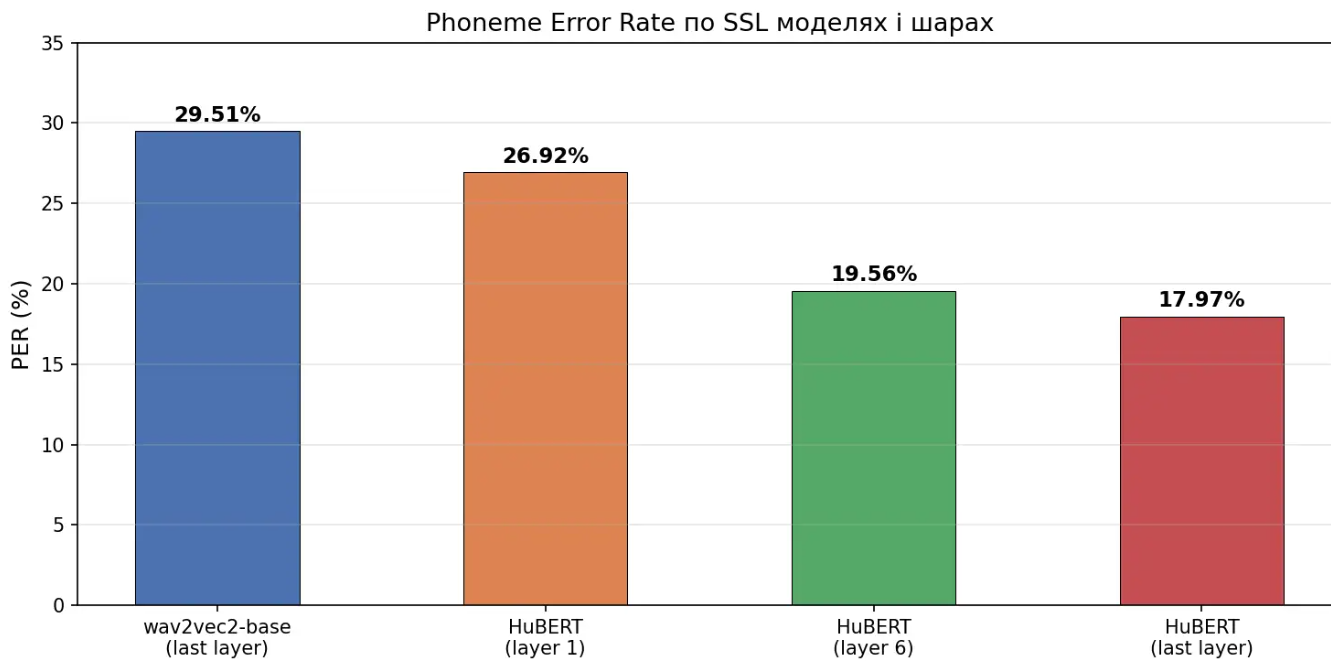

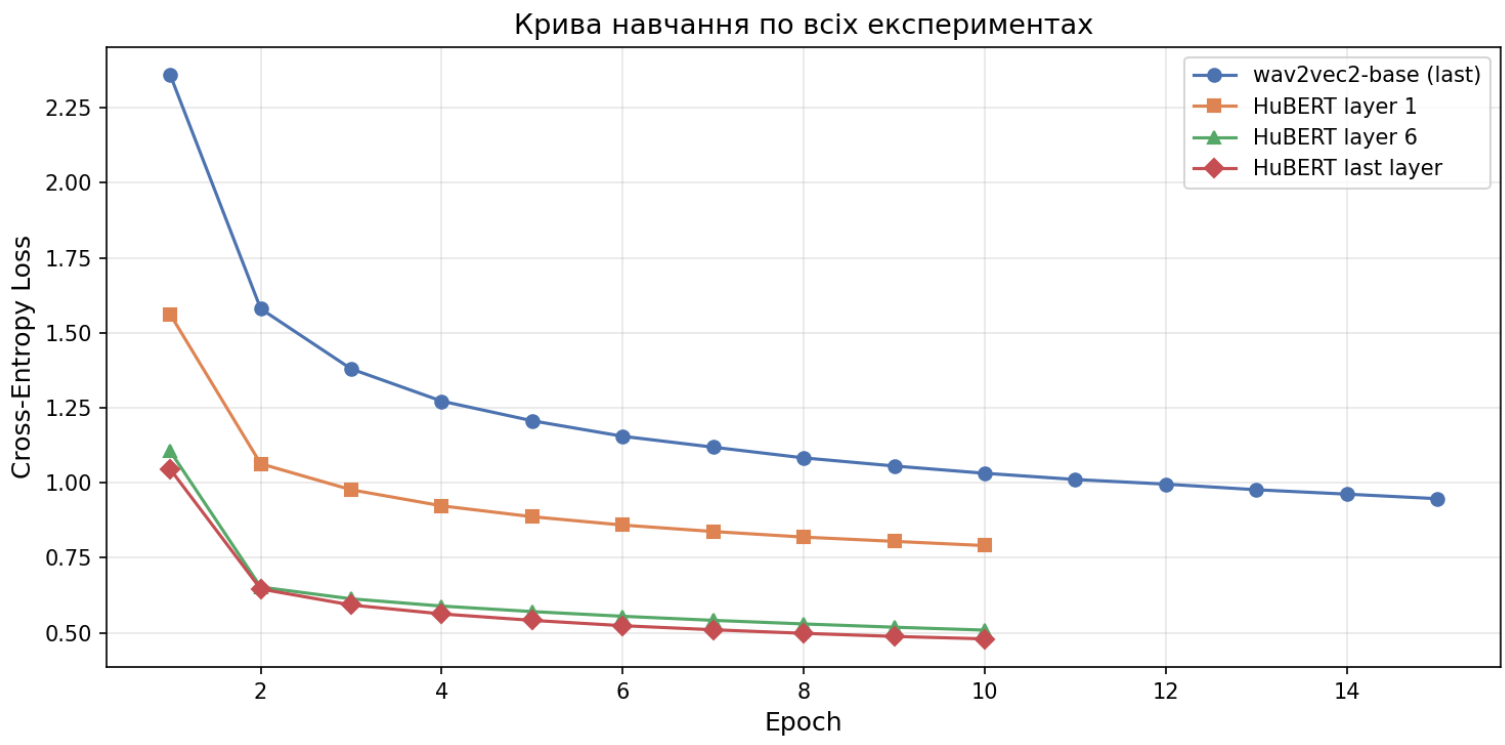

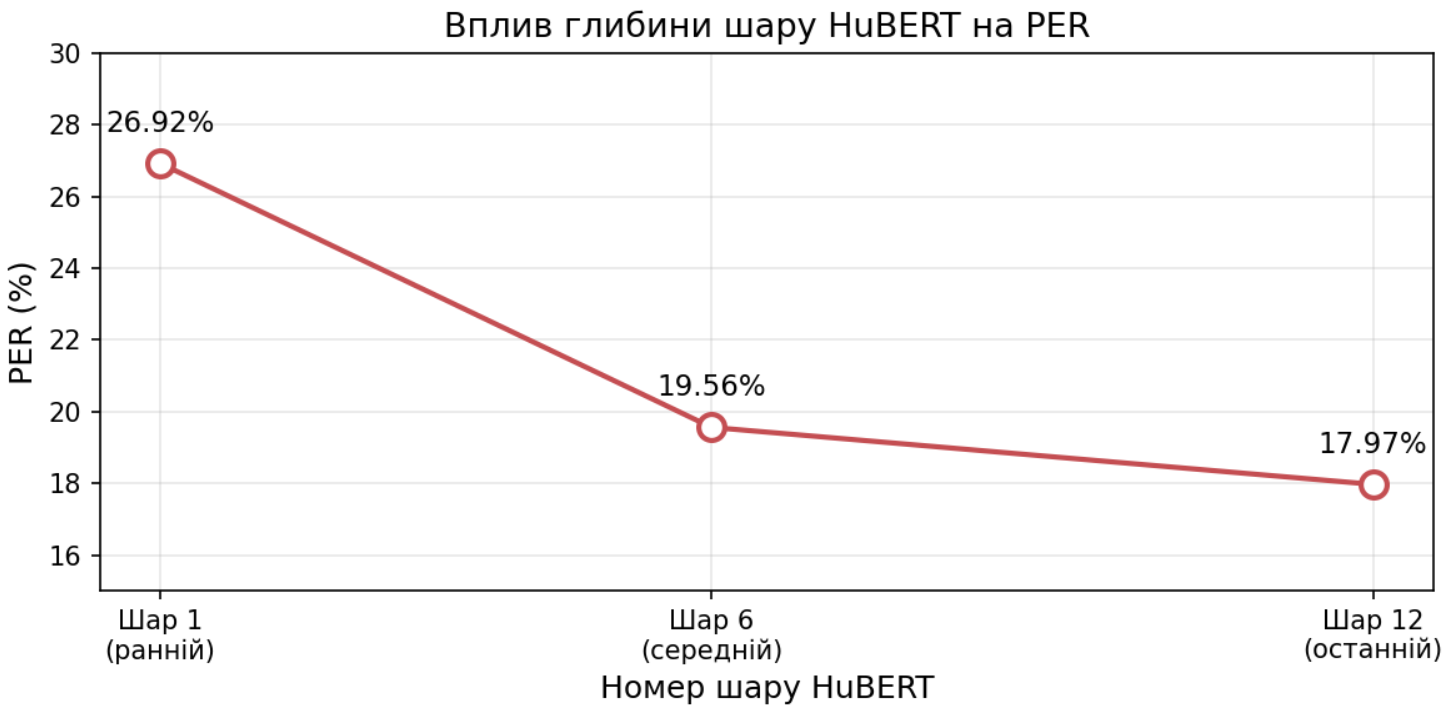


У літературі на TIMIT benchmark типові результати PER становлять 15–20% для підходів на основі SSL-моделей із простими класифікаторами. Отриманий результат 17.97% є конкурентним для frame-level класифікації з замороженим енкодером.


## Гіпотези й думки, щодо отриманих результатів

HuBERT значно краще за wav2vec2, оскільки HuBERT навчається передбачати приховані кластерні мітки для замаскованих аудіо-сегментів, що змушує модель вивчати дискретні фонетичні одиниці. wav2vec2 навчається через контрастивне завдання в неперервному просторі. Оскільки завдання HuBERT ближче до фонемної класифікації, його приховані стани краще відображають фонетичну структуру сигналу.

У статті HuBERT стверджується, що середні шари краще кодують фонемну інформацію, і це частково підтверджується: шар 6 (19.56%) кращий за шар 1 (26.92%). Однак у моєму експерименті останній шар (17.97%) виявився найкращим.

Можливе пояснення: Оскільки TIMIT чистий, акуратно розмічений датасет з простими акустичними умовами, в таких умовах вищі рівні абстракції (останній шар) несуть більше корисної інформації, ніж при роботі з зашумленим мовленням реального середовища, де середні шари можуть бути стабільнішими.

Ранній шар (layer 1) гірший за останній, але кращий за wav2vec2. Можливо, це тому, що Шар 1 HuBERT вже пройшов через CNN-енкодер та перший трансформер-шар, тому він несе базову акустичну інформацію, але ще не сформував повноцінних фонетичних репрезентацій. Проте навіть ці слабкі репрезентації HuBERT (26.92%) перевершують wav2vec2 last layer (29.51%).

## Висновки

SSL-моделі забезпечують якісні ознаки для фонемної класифікації навіть без fine-tuning. HuBERT суттєво перевершує wav2vec2. Глибина шару впливає на якість ознак: для TIMIT останній шар HuBERT є оптимальним, що може пояснюватись чистотою датасету.


## Завдання 2. Варіант 1. Аудіо фільтри для покращення якості TIMIT датасету

## Опис запропонованих алгоритмів фільтрування

Було розроблено чотири алгоритми фільтрування, кожен з яких вирішує окрему задачу обробки сигналу.

### Pre-emphasis

Фільтр підсилює високочастотні компоненти сигналу, компенсуючи природний спад спектра мовлення на високих частотах.

Формула:

```
y[t] = x[t] - α · x[t-1]
```

де `α = 0.97` - коефіцієнт pre-emphasis. Фільтр є FIR-фільтром першого порядку і реалізується за один прохід по сигналу. Основна мета: підвищити відношення сигнал/шум у високочастотному діапазоні, де знаходяться важливі ознаки приголосних фонем (шиплячі, свистячі).

### High-pass filter

High-pass фільтр прибирає низькочастотні компоненти сигналу нижче частоти зрізу. У реалізації використовувався цифровий biquad-фільтр (IIR другого порядку) з частотою зрізу 80 Гц.

Низькочастотний гул у такому діапазоні (гул мережі 50/60 Гц, вібрації підлоги, шум вентиляції) не несе корисної фонетичної інформації, тому його видалення теоретично може покращити якість ознак.

### Spectral noise reduction

Метод зменшення шуму базується на спектральному відніманні, алгоритмі, що оцінює профіль фонового шуму зі стаціонарних ділянок сигналу і віднімає його зі спектру. Реалізовано через бібліотеку `noisereduce` з параметром `stationary=True`, що відповідає умовам TIMIT (студійний запис зі стаціонарним шумовим фоном). Параметр `prop_decrease=0.75` задає агресивність фільтрації і 75% від оціненого шуму віднімається зі спектру.

### Peak normalization

Нормалізація гучності приводить всі аудіофайли до однакового рівня амплітуди:

```
y = x / max(|x|) · target_level
```

де `target_level = 0.95`. Мета: усунути варіативність гучності між різними дикторами та записами, яка може впливати на якість SSL-ознак. TIMIT містить записи від різних дикторів з різними мікрофонами та налаштуваннями, тому рівень гучності між файлами може суттєво відрізнятись.


## 2. Тестування покращення по PER метриці

Для оцінки впливу фільтрів на якість розпізнавання фонем проводилось абляційне дослідження: кожен фільтр тестувався окремо та у комбінації з іншими. В усіх експериментах використовувалась найкраща модель з Завдання 1 (*HuBERT-base (last layer)) з MLP класифікатором, 10 епох навчання, Adam optimizer (lr=1e-3), batch size 16.

Базовий результат (без фільтрів): PER = 17.97%

### Результати абляційного дослідження

| Конфігурація | PER (%) | Δ PER |
|---|---|---|
| Baseline (без фільтрів) | 17.97% | — |
| Pre-emphasis only | 18.04% | +0.07% |
| High-pass only | 18.09% | +0.12% |
| Noise reduction only | 18.08% | +0.11% |
| **Normalization only** | **17.90%** | **−0.07%** |
| All filters combined | 18.27% | +0.30% |

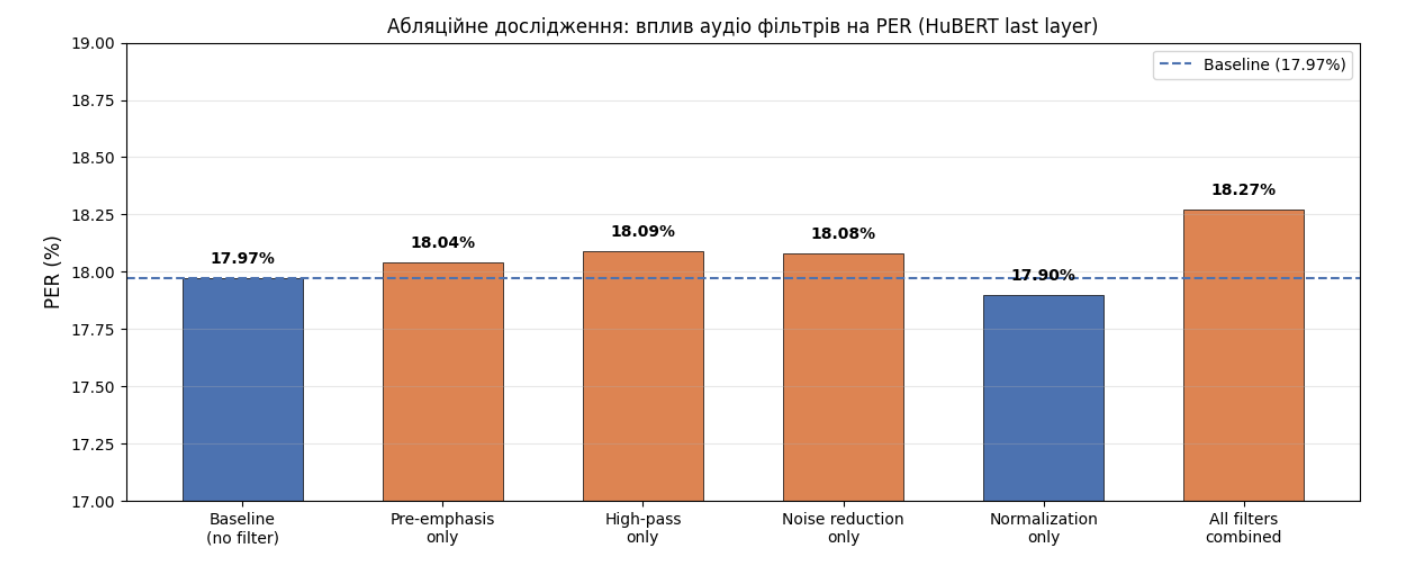


### Аналіз результатів

Жоден з фільтрів не дав статистично значущого покращення PER. Єдиний фільтр, що дав мінімальне покращення - нормалізація гучності (−0.07%). Комбінація всіх фільтрів дала найгірший результат (+0.30%) через накопиченням артефактів від кожного окремого фільтра.

Основна причина відсутності покращення у природі самого датасету. TIMIT є студійним датасетом, записаним у контрольованих акустичних умовах з мінімальним фоновим шумом. Класичні аудіо фільтри розроблені для покращення зашумлених записів реального середовища, тому на чистих студійних даних вони не мають що покращувати і навпаки можуть вносити артефакти, що погіршують якість вхідних ознак для SSL-моделі.

Також, причина може бути в тому, що SSL-модель HuBERT навчалась на нефільтрованих аудіо даних, і будь-яке фільтрування змінює статистику вхідного сигналу і потенційно виводить його за межі розподілу, на якому навчалась SSL-модель, що призводить до гіршої якості ознак.


## Об'єктивні метрики для оцінки якості даних

Окрім PER, для оцінки якості аудіо даних до і після фільтрації використовувались інші метрики:

### Signal-to-Noise Ratio

SNR (відношення сигнал/шум) вимірює, наскільки сильно фільтр змінив вхідний сигнал. У цьому випадку обчислювався як відношення потужності оригінального сигналу до потужності різниці між оригіналом і відфільтрованим сигналом:

```
SNR = 10 · log10(E[x²] / E[(x - y)²])
```

Висока абсолютна величина SNR означає сильні зміни сигналу. Від'ємний SNR означає, що фільтр вніс зміни більші за оригінальний сигнал (що типово для нормалізації тихих файлів).

###  Short-Time Objective Intelligibility

Метрика оцінки розбірливості мовлення, що вимірює кореляцію між короткочасними спектральними огинаючими оригінального і обробленого сигналу.

### PESQ (Perceptual Evaluation of Speech Quality)

Метрика, що моделює сприйняття якості мовлення людським вухом. Шкала від 1 до 4.5. Враховує розбірливість, та суб'єктивну комфортність прослуховування.


### Результати метрик якості

| Фільтр | SNR (dB) | STOI | Інтерпретація |
|---|---|---|---|
| Pre-emphasis | 0.26 | 0.9965 | Мінімальні зміни, розбірливість збережена |
| High-pass | 13.16 | 0.9993 | Прибирає вузький низькочастотний діапазон, майже не впливає на сигнал |
| Noise reduction | 5.22 | 0.9887 | Помірні зміни, незначне зниження розбірливості |
| Normalization | −15.72 | 1.0000 | Сильна зміна амплітуди (тихі файли підсилюються), але розбірливість ідеальна |
| All combined | −13.75 | 0.9838 | Найнижча розбірливість через накопичення ефектів фільтрів |

Інтерпретація SNR для нормалізації: від'ємний SNR (−15.72 dB) не означає погіршення якості, він відображає те, що деякі файли TIMIT мають дуже малу амплітуду і нормалізація різко збільшує їх гучність. Сам сигнал при цьому не спотворюється, що підтверджується ідеальним STOI = 1.0000.



## Висновки

Проведене дослідження показало, що класичні аудіо фільтри не дають покращення PER на датасеті, оскільки TIMIT студійний датасет з високою початковою якістю запису. Всі фільтри зберігають прийнятну розбірливість мовлення (STOI > 0.98), проте жоден не покращує якість SSL-ознак настільки, щоб це відобразилось на PER. Можна очікувати, що ті самі фільтри дадуть суттєве покращення на датасетах реального середовища, де присутній значний фоновий шум. У таких умовах зменшення шуму та нормалізація гучності можуть зменшити PER на кілька відсотків.